## **Neural Network**

In [1]:
import os
import json
import copy
import itertools
from itertools import cycle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import joblib

### Device Configuration & Reproducibility Setup

In [2]:
# Hardware configuration: prioritize NVIDIA CUDA (GPU) for faster training (if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if device.type == 'cuda':
    # Retrieve and print GPU details
    gpu_name = torch.cuda.get_device_name(0)
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"[INFO] Computation Device: GPU ({gpu_name})")
    print(f"[INFO] VRAM Available:   {total_mem:.2f} GB")
    print("[INFO] Status:           Ready for hardware acceleration.")
else:
    print("[WARNING] GPU not detected. The code will run on CPU.")

# Set random seeds for reproducibility.
# This ensures that initializing weights and shuffling data yields the same results every run.
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

[INFO] Computation Device: GPU (NVIDIA GeForce RTX 4050 Laptop GPU)
[INFO] VRAM Available:   6.44 GB
[INFO] Status:           Ready for hardware acceleration.


### Global Hyperparameters and Constants

In [3]:
# Total number of input features
# 805 = 768 (DistilBERT embeddings) + 37 (Manual feature engineering)
INPUT_DIM = 805   

# Number of target mental health categories
NUM_CLASSES = 5   

# Batch size for training
# Determines the number of samples processed per iteration; 64 is optimized for current GPU memory.
BATCH_SIZE = 64   

print("[INFO] Configuration loaded.")
print(f"       Input Features: {INPUT_DIM}")
print(f"       Target Classes: {NUM_CLASSES}")
print(f"       Batch Size:     {BATCH_SIZE}")

[INFO] Configuration loaded.
       Input Features: 805
       Target Classes: 5
       Batch Size:     64


### Data loading, Preprocessing & DataLoader Inizialization

In [4]:
print("-" * 80)
print("[DATA] Loading Pre-split Datasets...")

# Load datasets
df_train = pd.read_csv('../train_coded.csv')
df_test = pd.read_csv('../test_coded.csv')

# Feature and Label Separation
# Identify columns to drop (target label and any artifact indices from CSV)
cols_to_drop = [c for c in df_train.columns if 'Unnamed' in c or c == 'label']

X_train_full = df_train.drop(columns=cols_to_drop).values
y_train_full = df_train["label"].values

X_test = df_test.drop(columns=cols_to_drop).values
y_test = df_test["label"].values

# Feature Dimension Safety Check
# Ensure the dataset matches the expected input dimensions
print(f"[CHECK] Detected Features: {X_train_full.shape[1]} (Expected: {INPUT_DIM})")
if X_train_full.shape[1] != INPUT_DIM:
    raise ValueError(f"ERROR: Dataset has {X_train_full.shape[1]} columns, but INPUT_DIM is {INPUT_DIM}.")

# Validation Split
# Reserve 10% of training data for validating using stratified sampling
print("[PROCESS] Creating Validation Set from Training Data...")
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, 
    test_size=0.10,      
    random_state=SEED, 
    stratify=y_train_full 
)

# Normalization (StandardScaler)
# Fit only on training data to prevent data leakage, then transform all sets
print("[PROCESS] Applying StandardScaler (Z-Score)...")
scaler = StandardScaler()
scaler.fit(X_train) 

# Transform and convert to PyTorch Tensors
# Features become FloatTensors, Labels become LongTensors (required for CrossEntropyLoss)
X_train_scaled = torch.tensor(scaler.transform(X_train)).float()
X_val_scaled   = torch.tensor(scaler.transform(X_val)).float()
X_test_scaled  = torch.tensor(scaler.transform(X_test)).float()

y_train = torch.tensor(y_train.astype(int)).long() 
y_val   = torch.tensor(y_val.astype(int)).long()
y_test  = torch.tensor(y_test.astype(int)).long()

print("-" * 80)
print("[DATA] Final Preprocessed Shapes:")
print(f"       Training Set:   {X_train_scaled.shape}")
print(f"       Validation Set: {X_val_scaled.shape}")
print(f"       Test Set:       {X_test_scaled.shape}")
print("-" * 80)

# DataLoader Creation
# Wrap tensors into Datasets and create DataLoaders for efficient batching
train_dataset = TensorDataset(X_train_scaled, y_train)
val_dataset   = TensorDataset(X_val_scaled, y_val)
test_dataset  = TensorDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("[INFO] DataLoaders are ready.")

--------------------------------------------------------------------------------
[DATA] Loading Pre-split Datasets...
[CHECK] Detected Features: 805 (Expected: 805)
[PROCESS] Creating Validation Set from Training Data...
[PROCESS] Applying StandardScaler (Z-Score)...
--------------------------------------------------------------------------------
[DATA] Final Preprocessed Shapes:
       Training Set:   torch.Size([28782, 805])
       Validation Set: torch.Size([3198, 805])
       Test Set:       torch.Size([7996, 805])
--------------------------------------------------------------------------------
[INFO] DataLoaders are ready.


### NN Architecture Definition

In [5]:
class MentalHealthMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, dropout_rate):
        """
        Initializes the Multi-Layer Perceptron (MLP) architecture.
        
        Args:
            input_dim (int): Number of input features (805: 768 BERT + 37 Manual).
            hidden_dim (int): Number of neurons in the first hidden layer.
            num_classes (int): Number of output classes (target mental disorders).
            dropout_rate (float): Probability of zeroing an element for regularization.
        """
        super(MentalHealthMLP, self).__init__()
        
        self.network = nn.Sequential(
            # --- HIDDEN LAYER 1 ---
            # Projects high-dimensional input to the hidden feature space.
            nn.Linear(input_dim, hidden_dim),
            
            # Batch Normalization: Stabilizes learning and accelerates convergence.
            nn.BatchNorm1d(hidden_dim),
            
            # Activation Function (ReLU): Introduces non-linearity to capture complex patterns.
            nn.ReLU(),
            
            # Dropout: Prevents overfitting by randomly deactivating neurons.
            nn.Dropout(dropout_rate),
            
            # --- HIDDEN LAYER 2 ---
            # Compresses features further (bottleneck) before classification.
            # We reduce dimensions by half (hidden_dim // 2) to force feature abstraction.
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.BatchNorm1d(hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            
            # --- OUTPUT LAYER ---
            # Maps the final features to raw class scores (logits).
            # Note: No Softmax is applied here because CrossEntropyLoss includes it internally.
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        # Defines the forward pass logic
        return self.network(x)

print("[INFO] Model Architecture class defined.")

[INFO] Model Architecture class defined.


### Training and Evaluation Helper Functions

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Performs one complete training pass (epoch) over the dataset.
    Updates model weights based on the calculated loss.
    """
    model.train() # Set model to training mode (enables Dropout/BatchNorm)
    
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    for inputs, labels in loader:
        # Move batch to the configured device (GPU/CPU)
        inputs, labels = inputs.to(device), labels.to(device)
        
        # Clear previous gradients to prevent accumulation
        optimizer.zero_grad()
        
        # Forward Pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward Pass (Backpropagation) & Weight Update
        loss.backward()
        optimizer.step()
        
        # Metric Tracking
        running_loss += loss.item()
        _, predicted_class = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted_class == labels).sum().item()
        
    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct_predictions / total_samples
    return avg_loss, accuracy

def evaluate_model(model, loader, criterion, device):
    """
    Evaluates the model on Validation/Test data.
    Does NOT update weights and disables gradient calculation for efficiency.
    """
    model.eval() # Set model to evaluation mode (disables Dropout/BatchNorm)
    
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    with torch.no_grad(): # Disable gradient calculation to save memory/compute
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Forward Pass Only
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            # Metric Tracking
            running_loss += loss.item()
            _, predicted_class = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted_class == labels).sum().item()
            
    avg_loss = running_loss / len(loader)
    accuracy = 100 * correct_predictions / total_samples
    return avg_loss, accuracy

print("[INFO] Helper functions compiled.")

[INFO] Helper functions compiled.


### Hyperparameter Grid Search with History Tracking

In [7]:
# Define the hyperparameter search space
param_grid = {
    'lr': [0.001, 0.0001, 0.0005],     # Learning Rates
    'hidden_dim': [512, 256],          # Neuron count in hidden layers
    'dropout': [0.2, 0.3, 0.5]         # Regularization strength
}

# Generate all possible combinations (Cartesian product)
keys, values = zip(*param_grid.items())
configs = [dict(zip(keys, v)) for v in itertools.product(*values)]

# Dictionary to store training metrics for every configuration (for later plotting)
all_histories = {} 

# Tracking best overall performance
best_val_accuracy = 0.0
best_model_weights = None
best_config = None

print(f"[PROCESS] Starting Grid Search on {len(configs)} configurations...")

for idx, config in enumerate(configs):
    config_name = f"Config {idx+1} (LR={config['lr']}, Hidden={config['hidden_dim']}, Drop={config['dropout']})"
    print(f"\n[EXPERIMENT] Running {config_name}")
    
    # Initialize Model with current configuration parameters
    model = MentalHealthMLP(INPUT_DIM, config['hidden_dim'], NUM_CLASSES, config['dropout']).to(device)
    
    # Loss Function and Optimizer
    # AdamW is used for better weight decay handling compared to standard Adam
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=0.01)
    
    # Local history storage for this specific run
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [],  'val_acc': []
    }
    
    # Early Stopping parameters
    patience_limit = 5
    patience_counter = 0
    min_val_loss = float('inf')
    max_epochs = 50
    
    for epoch in range(max_epochs):
        # Execute Training and Evaluation steps
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        v_loss, v_acc = evaluate_model(model, val_loader, criterion, device)
        
        # Store metrics
        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        print(f"   Ep {epoch+1:02d} | T_Loss: {t_loss:.4f} T_Acc: {t_acc:.1f}% | V_Loss: {v_loss:.4f} V_Acc: {v_acc:.1f}%")
        
        # Check for improvement (Early Stopping logic)
        if v_loss < min_val_loss:
            min_val_loss = v_loss
            patience_counter = 0
            
            # If this is the best model globally so far, save it
            if v_acc > best_val_accuracy:
                best_val_accuracy = v_acc
                # Deepcopy is essential to save the *values* of weights, not just the reference
                best_model_weights = copy.deepcopy(model.state_dict())
                best_config = config
        else:
            patience_counter += 1
            if patience_counter >= patience_limit:
                print(f"   [STOP] Early stopping triggered.")
                break
    
    # Save the full history of this configuration to the global dictionary
    all_histories[config_name] = history

print("\n[RESULT] Grid Search Complete.")
print(f"Best Validation Accuracy: {best_val_accuracy:.2f}%")
print(f"Best Configuration:       {best_config}")

[PROCESS] Starting Grid Search on 18 configurations...

[EXPERIMENT] Running Config 1 (LR=0.001, Hidden=512, Drop=0.2)
   Ep 01 | T_Loss: 1.0689 T_Acc: 58.9% | V_Loss: 0.9696 V_Acc: 62.9%
   Ep 02 | T_Loss: 0.9423 T_Acc: 64.9% | V_Loss: 0.9298 V_Acc: 64.6%
   Ep 03 | T_Loss: 0.8946 T_Acc: 66.7% | V_Loss: 0.9074 V_Acc: 65.4%
   Ep 04 | T_Loss: 0.8602 T_Acc: 68.2% | V_Loss: 0.9017 V_Acc: 66.2%
   Ep 05 | T_Loss: 0.8273 T_Acc: 69.3% | V_Loss: 0.8949 V_Acc: 66.9%
   Ep 06 | T_Loss: 0.7990 T_Acc: 70.5% | V_Loss: 0.9046 V_Acc: 66.0%
   Ep 07 | T_Loss: 0.7669 T_Acc: 71.6% | V_Loss: 0.8960 V_Acc: 66.9%
   Ep 08 | T_Loss: 0.7422 T_Acc: 72.4% | V_Loss: 0.9188 V_Acc: 65.5%
   Ep 09 | T_Loss: 0.7093 T_Acc: 73.7% | V_Loss: 0.9318 V_Acc: 66.1%
   Ep 10 | T_Loss: 0.6824 T_Acc: 74.9% | V_Loss: 0.9255 V_Acc: 66.4%
   [STOP] Early stopping triggered.

[EXPERIMENT] Running Config 2 (LR=0.001, Hidden=512, Drop=0.3)
   Ep 01 | T_Loss: 1.0828 T_Acc: 58.7% | V_Loss: 0.9667 V_Acc: 62.7%
   Ep 02 | T_Loss: 0.9

### Performance Visualization: Top 3 Configurations

TOP 3 CONFIGURATIONS BY VALIDATION ACCURACY:
1. Config 18 (LR=0.0005, Hidden=256, Drop=0.5) | Best Val Acc: 68.73%
2. Config 6 (LR=0.001, Hidden=256, Drop=0.5) | Best Val Acc: 68.32%
3. Config 12 (LR=0.0001, Hidden=256, Drop=0.5) | Best Val Acc: 68.20%



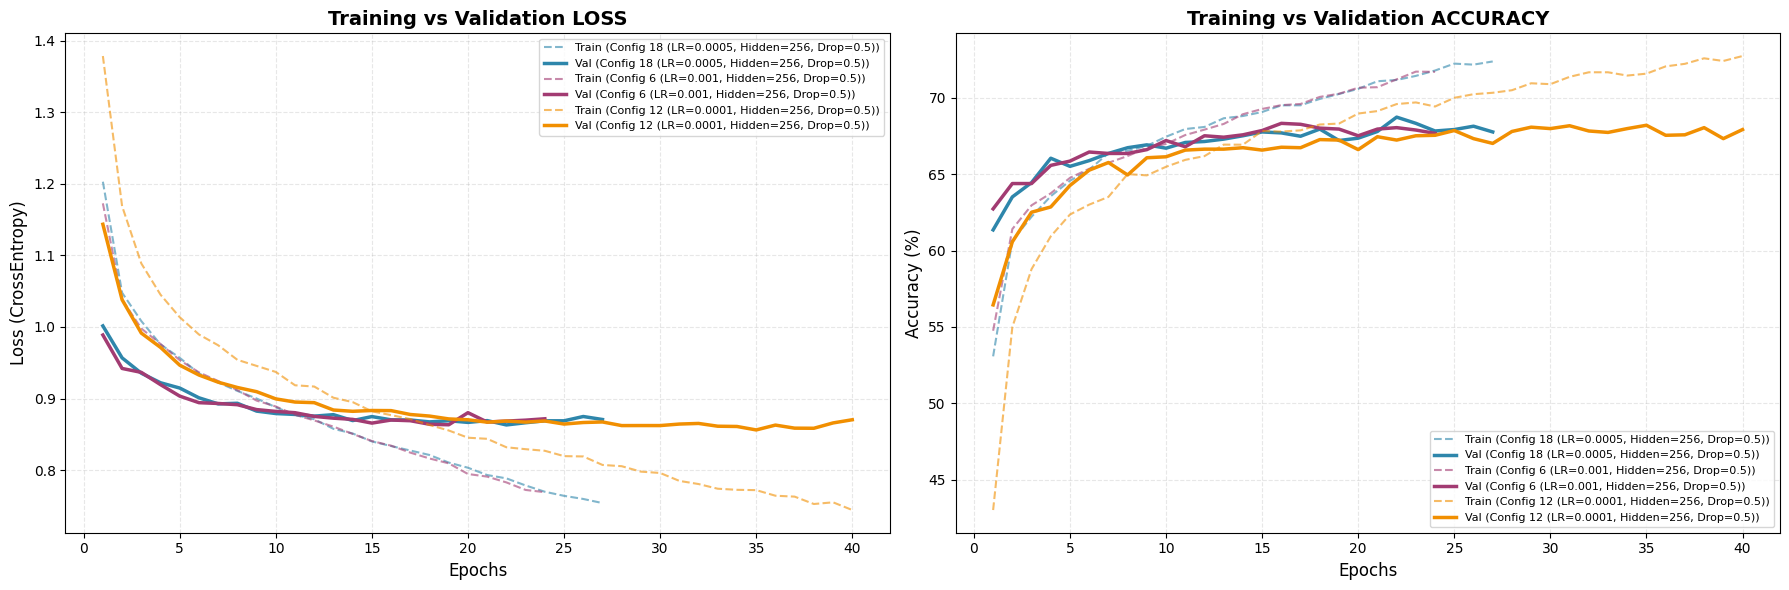

In [8]:
# Check availability of training history
if 'all_histories' not in locals() or not all_histories:
    print("[ERROR] No training history found. Please run the training cell first.")
else:
    # Identify the top 3 configurations based on maximum validation accuracy
    config_best_val_acc = {
        config_name: max(history['val_acc']) 
        for config_name, history in all_histories.items()
    }
    
    # Sort descending by accuracy and slice the top 3
    top_3_configs = sorted(config_best_val_acc.items(), key=lambda x: x[1], reverse=True)[:3]
    top_3_names = [config[0] for config in top_3_configs]
    
    print("TOP 3 CONFIGURATIONS BY VALIDATION ACCURACY:")
    for i, (config_name, best_acc) in enumerate(top_3_configs, 1):
        print(f"{i}. {config_name:30s} | Best Val Acc: {best_acc:.2f}%")
    print()
    
    # Initialize plotting environment
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Distinct colors for clarity
    colors = ['#2E86AB', '#A23B72', '#F18F01']
    
    # Iterate through the top performers
    for idx, config_name in enumerate(top_3_names):
        history = all_histories[config_name]
        epochs = range(1, len(history['train_loss']) + 1)
        color = colors[idx]
        
        # --- PLOT 1: LOSS (Lower is better) ---
        # Dashed line = Training, Solid line = Validation
        ax1.plot(epochs, history['train_loss'], linestyle='--', alpha=0.6, 
                 color=color, label=f'Train ({config_name})')
        ax1.plot(epochs, history['val_loss'], linestyle='-', linewidth=2.5, 
                 color=color, label=f'Val ({config_name})')
        
        # --- PLOT 2: ACCURACY (Higher is better) ---
        ax2.plot(epochs, history['train_acc'], linestyle='--', alpha=0.6, 
                 color=color, label=f'Train ({config_name})')
        ax2.plot(epochs, history['val_acc'], linestyle='-', linewidth=2.5, 
                 color=color, label=f'Val ({config_name})')

    # Styling Plot 1 (Loss)
    ax1.set_title('Training vs Validation LOSS', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Loss (CrossEntropy)', fontsize=12)
    ax1.grid(True, which='both', linestyle='--', alpha=0.3)
    # Legend location optimized to avoid covering data
    ax1.legend(loc='upper right', fontsize=8)

    # Styling Plot 2 (Accuracy)
    ax2.set_title('Training vs Validation ACCURACY', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.grid(True, which='both', linestyle='--', alpha=0.3)
    ax2.legend(loc='lower right', fontsize=8)

    plt.tight_layout()
    plt.show()

### Final model evaluation on Test Set + Confusion matrix

[PROCESS] Loading best model for final inference...
[PROCESS] Running inference on Test Set...

FINAL CLASSIFICATION REPORT
               precision    recall  f1-score   support

          BPD     0.6844    0.6288    0.6554      1600
      Bipolar     0.6649    0.6225    0.6430      1600
   Depression     0.6441    0.7194    0.6797      1600
      Anxiety     0.7291    0.7319    0.7305      1600
Schizophrenia     0.7058    0.7231    0.7143      1596

     accuracy                         0.6851      7996
    macro avg     0.6857    0.6851    0.6846      7996
 weighted avg     0.6856    0.6851    0.6846      7996



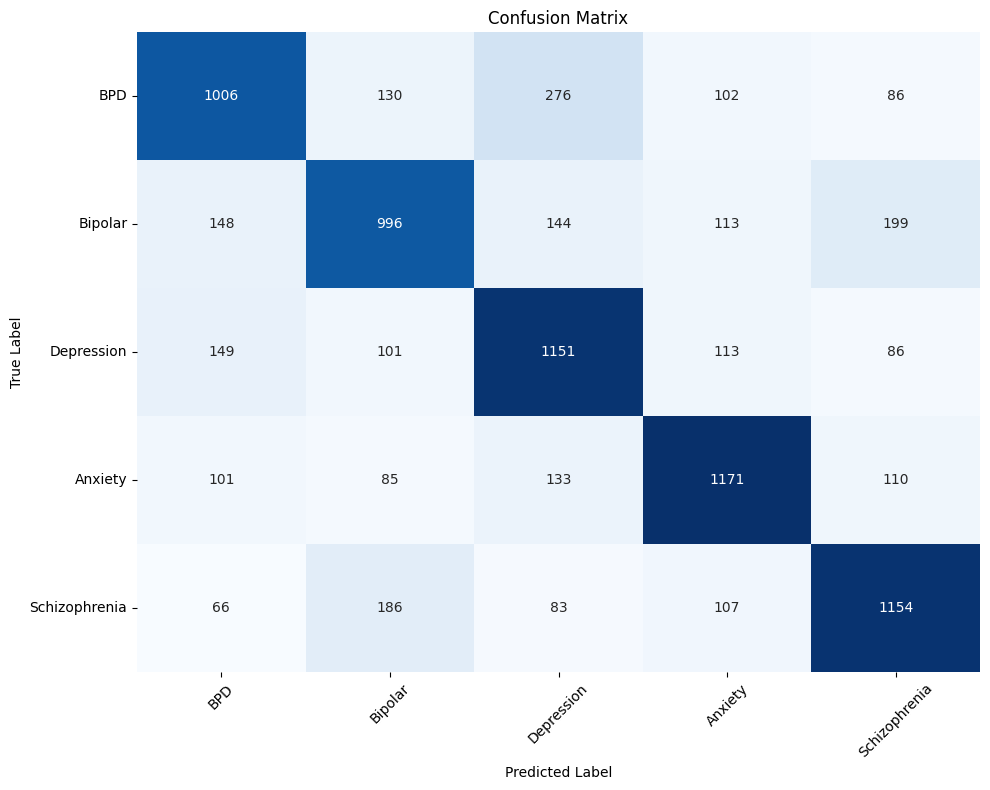

In [9]:
print("[PROCESS] Loading best model for final inference...")

# Re-instantiate the model using the optimal hyperparameters found during Grid Search
final_model = MentalHealthMLP(
    input_dim=INPUT_DIM, 
    hidden_dim=best_config['hidden_dim'], 
    num_classes=NUM_CLASSES, 
    dropout_rate=best_config['dropout']
)

# Load the best weights saved during training (from the epoch with highest Val Acc)
final_model.load_state_dict(best_model_weights)
final_model.to(device)
final_model.eval()

all_predictions = []
all_ground_truth = []

print("[PROCESS] Running inference on Test Set...")

# Inference Loop
# We disable gradient calculation to save memory and computation
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        
        # Forward pass
        outputs = final_model(inputs)
        
        # Get the class index with the highest probability
        _, predicted = torch.max(outputs, 1)
        
        # Move to CPU and convert to numpy for Scikit-Learn compatibility
        all_predictions.extend(predicted.cpu().numpy())
        all_ground_truth.extend(labels.numpy())

print("\nFINAL CLASSIFICATION REPORT")

# Define class names for the report
# Ensure this order strictly matches the integer encoding used during data prep
target_class_names = ["BPD", "Bipolar", "Depression", "Anxiety", "Schizophrenia"] 

# Generate textual report
report = classification_report(
    all_ground_truth, 
    all_predictions, 
    target_names=target_class_names,
    digits=4
)
print(report)

# Generate Confusion Matrix
cm = confusion_matrix(all_ground_truth, all_predictions)

# Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True,         # Display numerical values
    fmt='d',            # Format as integers
    cmap='Blues',       # Color gradient
    cbar=False,         
    xticklabels=target_class_names, 
    yticklabels=target_class_names
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### ROC curve

[PROCESS] Calculating probabilities for ROC Curves...


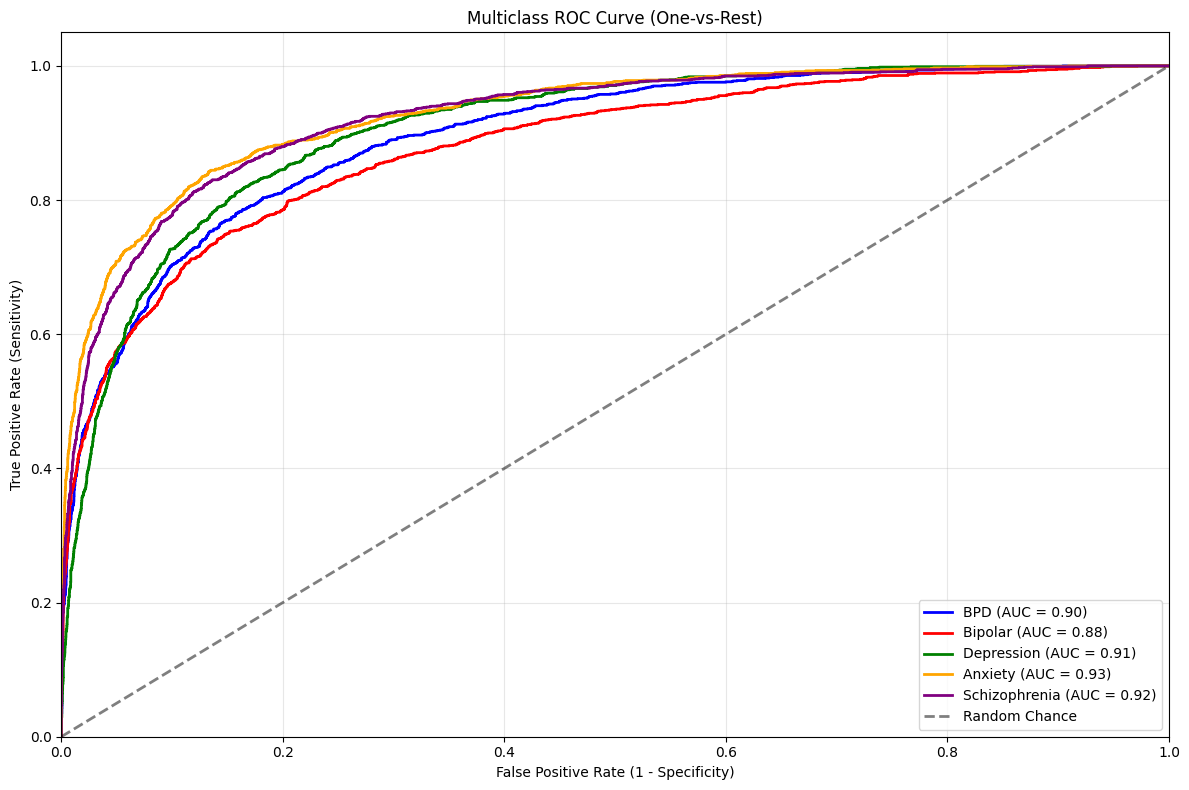

In [10]:
print("[PROCESS] Calculating probabilities for ROC Curves...")

# Compute Probabilities (Softmax)
# We need explicit probabilities (0.0 - 1.0) for ROC analysis.
final_model.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        
        # Forward pass: obtain raw logits
        logits = final_model(inputs)
        
        # Apply Softmax to convert logits to probabilities
        probs = torch.softmax(logits, dim=1)
        
        # Move to CPU and convert to Numpy
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

# Convert lists to Numpy arrays
y_test_numpy = np.array(all_labels)
y_pred_proba = np.array(all_probs)

# Binarize Labels (One-Hot Encoding)
# Necessary for One-vs-Rest strategy: e.g., Class 2 becomes [0, 0, 1, 0, 0]
y_test_bin = label_binarize(y_test_numpy, classes=range(NUM_CLASSES))

# Calculate ROC and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(NUM_CLASSES):
    # Calculate ROC for class i vs. all other classes
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting ROC Curves
plt.figure(figsize=(12, 8))
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])

# Ensure these match the encoding order (0, 1, 2, 3, 4)
target_class_names = ["BPD", "Bipolar", "Depression", "Anxiety", "Schizophrenia"] 

for i, color in zip(range(NUM_CLASSES), colors):
    label_text = f'{target_class_names[i]} (AUC = {roc_auc[i]:.2f})'
    plt.plot(fpr[i], tpr[i], color=color, lw=2, label=label_text)

# Plot "Random Guess" baseline (diagonal)
plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.5, label='Random Chance')

# Plot styling
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Multiclass ROC Curve (One-vs-Rest)')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Performance metrics per class

[PROCESS] Generating per-class performance bar chart...


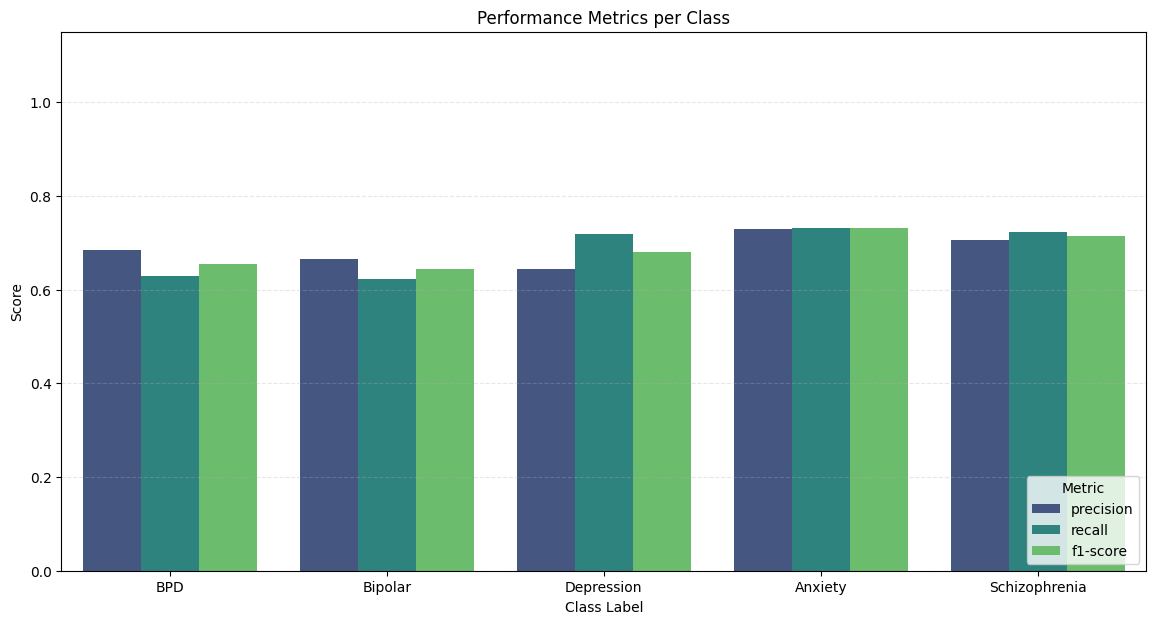

In [11]:
print("[PROCESS] Generating per-class performance bar chart...")

# Prepare Data
# Reuse the lists generated in the previous inference cell
y_test_data = all_ground_truth
y_pred_data = all_predictions

# Define class labels mapping (Index -> Name)
# We use the list 'target_class_names' defined previously.
# Ensure strictly that the order matches your data encoding (0, 1, 2...).
class_labels_map = {i: name for i, name in enumerate(target_class_names)}

# Generate Classification Report as Dictionary
report_dict = classification_report(
    y_test_data, 
    y_pred_data, 
    output_dict=True,
    zero_division=0 # Handles cases where a class is never predicted
)

# Convert to DataFrame and Clean
df_metrics = pd.DataFrame(report_dict).transpose()

# Remove 'accuracy', 'macro avg', and 'weighted avg' rows to focus purely on classes
df_metrics_classes = df_metrics.drop(['accuracy', 'macro avg', 'weighted avg']).copy()

# Map the numeric index string ("0", "1"...) to actual class names ("Anxiety", "BPD"...)
# We cast to int first to ensure matching with our dictionary keys
df_metrics_classes.index = df_metrics_classes.index.astype(int).map(class_labels_map)

# Reshape data for Seaborn (Melting)
# Convert from wide format (columns: Precision, Recall, F1) to long format for plotting
df_melted = df_metrics_classes[['precision', 'recall', 'f1-score']].reset_index()
df_melted = df_melted.melt(id_vars='index', var_name='Metric', value_name='Score')

# Plotting
plt.figure(figsize=(14, 7))

chart = sns.barplot(
    data=df_melted, 
    x='index', 
    y='Score', 
    hue='Metric', 
    palette='viridis'
)

# Styling
plt.title('Performance Metrics per Class')
plt.xlabel('Class Label')
plt.ylabel('Score')
plt.ylim(0, 1.15)  
plt.legend(title='Metric', loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0) 
plt.show()

### Saving Model Artifacts for Deployment

In [12]:
print("[PROCESS] Saving model artifacts...")

# Define the output directory
output_dir = "nn_artifacts"

# Create the directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"[INFO] Created directory: '{output_dir}'")

# Save the Neural Network Weights (State Dict)
# We save only the weights (state_dict), not the entire model object, for portability.
model_path = os.path.join(output_dir, "mental_health_mlp_weights.pth")
torch.save(final_model.state_dict(), model_path)
print(f"[SAVE] Model weights saved to: '{model_path}'")

# Save the Scaler (StandardScaler)
# New data must be scaled using the EXACT same mean/std as the training data.
scaler_path = os.path.join(output_dir, "scaler.pkl")
joblib.dump(scaler, scaler_path)
print(f"[SAVE] StandardScaler saved to: '{scaler_path}'")

# Save Configuration & Class Names
# Required to reconstruct the model architecture before loading weights.
config_path = os.path.join(output_dir, "model_config.json")
model_metadata = {
    "input_dim": INPUT_DIM,
    "hidden_dim": best_config['hidden_dim'],
    "num_classes": NUM_CLASSES,
    "dropout": best_config['dropout'],
    "class_names": target_class_names
}

with open(config_path, 'w') as f:
    json.dump(model_metadata, f, indent=4)
print(f"[SAVE] Model configuration saved to: '{config_path}'")

print("-" * 60)
print(f"ALL FILES SAVED SUCCESSFULLY.")
print("To reuse this model, you will need all three files.")
print("-" * 60)

[PROCESS] Saving model artifacts...
[SAVE] Model weights saved to: 'nn_artifacts\mental_health_mlp_weights.pth'
[SAVE] StandardScaler saved to: 'nn_artifacts\scaler.pkl'
[SAVE] Model configuration saved to: 'nn_artifacts\model_config.json'
------------------------------------------------------------
ALL FILES SAVED SUCCESSFULLY.
To reuse this model, you will need all three files.
------------------------------------------------------------
